# **Bare Slab Reactor — Diffusion Eigenvalue Problem**

## Introduction

This notebook solves the one-dimensional neutron diffusion eigenvalue problem
for a homogeneous bare slab reactor.

The diffusion equation is discretised using a second-order central
finite-difference scheme and written as a matrix eigenvalue problem.

The numerical solution is validated against the analytical solution for a
homogeneous slab by comparing:

- the effective multiplication factor $k_{\mathrm{eff}}$,
- the analytical fundamental eigenvalue, and
- the shape of the fundamental neutron flux.

The flux is normalised before comparison because its absolute magnitude is
arbitrary in an eigenvalue problem.

## Theory

For a one-dimensional homogeneous reactor, the steady-state one-group
diffusion equation can be written as

$$
-D\frac{d^2\phi}{dx^2}
+\Sigma_a\phi
=
\frac{1}{k}\nu\Sigma_f\phi,
$$

where:

- $D$ is the diffusion coefficient,
- $\Sigma_a$ is the macroscopic absorption cross section,
- $\nu\Sigma_f$ is the neutron production cross section,
- $\phi(x)$ is the neutron flux, and
- $k$ is the effective multiplication factor.

Rearranging gives

$$
\frac{1}{\nu\Sigma_f}
\left(
-D\frac{d^2}{dx^2}+\Sigma_a
\right)\phi
=
\frac{1}{k}\phi.
$$

This has the form of a matrix eigenvalue problem,

$$
M\boldsymbol{\phi}
=
\lambda\boldsymbol{\phi},
$$

where

$$
\lambda=\frac{1}{k}.
$$

Therefore, the largest value of $k$ corresponds to the smallest eigenvalue
of $M$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reactor parameters
D = 0.9              # Diffusion coefficient [cm]
Sigma_a = 0.1        # Macroscopic absorption cross section [1/cm]
nu_Sigma_f = 0.12    # Neutron production cross section [1/cm]

# Spatial domain
a = 200.0            # Slab width [cm]
N = 500              # Number of interior grid points

# Uniform interior grid
dx = a / (N + 1)
x = np.linspace(dx, a - dx, N)

print(f"Grid spacing: dx = {dx:.4f} cm")
print(f"Number of interior points: N = {N}")

Grid spacing: dx = 0.3992 cm
Number of interior points: N = 500


## Numerical Method

The second derivative is approximated using the central finite-difference
formula

$$
\frac{d^2\phi}{dx^2}
\approx
\frac{\phi_{i-1}-2\phi_i+\phi_{i+1}}{(\Delta x)^2}.
$$

This gives the diffusion operator the tridiagonal form

$$
-\frac{d^2}{dx^2}
\approx
\frac{1}{(\Delta x)^2}
\begin{pmatrix}
2 & -1 & 0 & \cdots & 0\\
-1 & 2 & -1 & \cdots & 0\\
0 & -1 & 2 & \ddots & 0\\
\vdots & \vdots & \ddots & \ddots & -1\\
0 & 0 & 0 & -1 & 2
\end{pmatrix}.
$$

Only the interior grid points are represented explicitly. The boundary
conditions are

$$
\phi(0)=\phi(a)=0.
$$

The resulting matrix problem is

$$
\frac{1}{\nu\Sigma_f}
\left(L+\Sigma_a I\right)
\boldsymbol{\phi}
=
\frac{1}{k}\boldsymbol{\phi},
$$

where $L$ is the discretised diffusion operator.

In [2]:
# Construct the finite-difference diffusion operator
main_diag = 2.0 * D * np.ones(N) / dx**2
off_diag = -D * np.ones(N - 1) / dx**2

L = (
    np.diag(main_diag)
    + np.diag(off_diag, k=1)
    + np.diag(off_diag, k=-1)
)

# Add the absorption term
A_matrix = L + Sigma_a * np.eye(N)

# Convert to the standard eigenvalue form:
# M phi = (1/k) phi
M = A_matrix / nu_Sigma_f

## Implementation

The matrix $M$ is real and symmetric, so `numpy.linalg.eigh` can be used to
calculate its eigenvalues and eigenvectors.

Since the eigenvalues satisfy

$$
\lambda=\frac{1}{k},
$$

the largest multiplication factor corresponds to the smallest eigenvalue.

In [3]:
# Solve the matrix eigenvalue problem
eigenvalues, eigenvectors = np.linalg.eigh(M)

# Convert eigenvalues lambda = 1/k into multiplication factors
k_values = 1.0 / eigenvalues

# Fundamental mode: largest multiplication factor
k_eff = np.max(k_values)

print(f"k_eff = {k_eff:.6f}")

k_eff = 1.197341


## Results

### Effective Multiplication Factor

The numerical effective multiplication factor is

$$
k_{\mathrm{eff}} = 1.197341.
$$

The analytical solution gives

$$
k_{\mathrm{analytical}} = 1.197341.
$$

The relative error is

$$
\frac{|k_{\mathrm{eff}}-k_{\mathrm{analytical}}|}
{k_{\mathrm{analytical}}}
=7.26\times10^{-9}.
$$

The numerical result therefore agrees extremely closely with the analytical
solution for the chosen grid.

In [4]:
# Analytical fundamental multiplication factor
B_squared = (np.pi / a)**2

k_analytical = (
    nu_Sigma_f
    / (Sigma_a + D * B_squared)
)

relative_error = abs(
    k_eff - k_analytical
) / k_analytical

print(f"k_eff (numerical): {k_eff:.6f}")
print(f"k_analytical:      {k_analytical:.6f}")
print(f"Relative error:    {relative_error:.2e}")

k_eff (numerical): 1.197341
k_analytical:      1.197341
Relative error:    7.26e-09


### Fundamental Flux Mode

The numerical fundamental flux is compared with the analytical solution

$$
\phi(x)=\sin\left(\frac{\pi x}{a}\right).
$$

The $L^2$ error between the normalised numerical and analytical flux profiles
is

$$
\|\phi_{\mathrm{numerical}}-\phi_{\mathrm{analytical}}\|_2
=1.04\times10^{-12}.
$$

This very small error indicates that the numerical solution reproduces the
analytical shape of the fundamental flux extremely accurately.

In [5]:
# Extract the fundamental eigenvector
idx_fundamental = np.argmin(eigenvalues)

phi_numerical = eigenvectors[:, idx_fundamental]

# Analytical fundamental flux
phi_analytical = np.sin(np.pi * x / a)

# Normalise both fluxes to the same peak value
phi_numerical /= np.max(np.abs(phi_numerical))
phi_analytical /= np.max(np.abs(phi_analytical))

# Adjust the overall sign for comparison
if np.dot(phi_numerical, phi_analytical) < 0:
    phi_numerical = -phi_numerical

# Calculate the L2 error
l2_error = np.sqrt(
    np.sum((phi_numerical - phi_analytical)**2) * dx
)

print(f"Flux shape L2 error: {l2_error:.2e}")

Flux shape L2 error: 1.04e-12


### Flux Profile

The numerical and analytical fundamental flux profiles are plotted together
to compare their spatial dependence.

Both profiles are normalised, so the comparison focuses on the shape of the
fundamental mode rather than its arbitrary absolute magnitude.

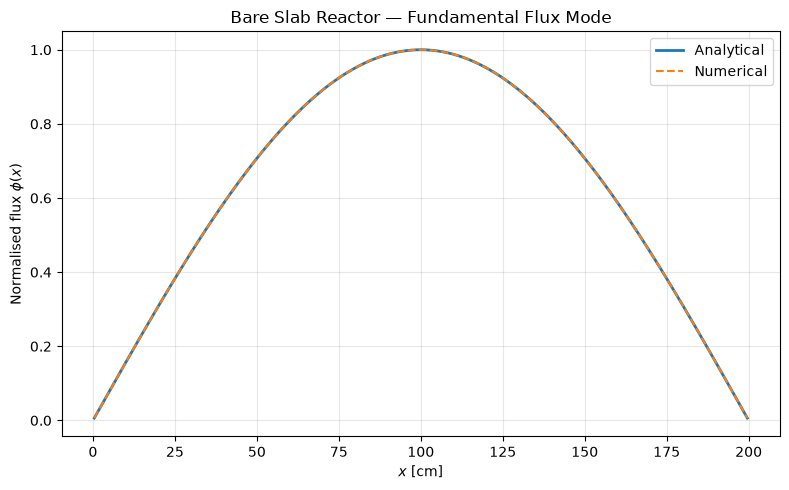

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    x,
    phi_analytical,
    label="Analytical",
    linewidth=2
)

plt.plot(
    x,
    phi_numerical,
    "--",
    label="Numerical",
    linewidth=1.5
)

plt.xlabel("$x$ [cm]")
plt.ylabel(r"Normalised flux $\phi(x)$")
plt.title("Bare Slab Reactor — Fundamental Flux Mode")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../assets/bare_slab_flux_profile.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Discussion

The numerical calculation agrees very closely with the analytical solution
for the homogeneous bare slab.

The relative error in the effective multiplication factor is
$7.26\times10^{-9}$, while the $L^2$ error in the normalised fundamental
flux is $1.04\times10^{-12}$. Both errors are very small for the grid used
in this calculation.

The flux profile also reproduces the expected sinusoidal shape of the
fundamental mode. This provides a strong check that both the discretised
diffusion operator and the eigenvalue formulation have been implemented
correctly.

The calculated value $k_{\mathrm{eff}}=1.197341$ is greater than one,
indicating that the reactor is supercritical for the chosen material
properties and geometry. In this model, neutron production therefore exceeds
neutron losses through absorption and leakage.

The agreement is expected for this simple homogeneous geometry, where an
analytical solution is available. More complicated reactor configurations
may not have a closed-form solution and will therefore require numerical
methods alone.

## Conclusion

A one-dimensional finite-difference model of a homogeneous bare slab reactor
was implemented as a matrix eigenvalue problem.

The numerical effective multiplication factor,
$k_{\mathrm{eff}}=1.197341$, agrees with the analytical value to a relative
error of $7.26\times10^{-9}$. The fundamental numerical flux also agrees
closely with the analytical sinusoidal solution, with an $L^2$ error of
$1.04\times10^{-12}$.

These results validate the finite-difference formulation for the bare slab
case and provide a reliable starting point for studying more complicated
reactor configurations.